In [1]:
import numpy as np

# August 29
**Class Overview**

1) Computer representation of numbers:

- integers, real numbers

2) The four linear algebra problems ||| Lin Alg Methods ||| Modern Methods

i) Linear systems ||| Gaussian Elimination ||| Gaussian Elimination with Partial Pivoting

ii) Least Squares problems ||| Normal equations + Gram-Schmidt ||| Reflectors / Rotators

iii) Eigenvalue Problems ||| Find the characteristic polynomial ||| the QR iteration

iv) Singular Value Problems ||| ? ||| 

3) What if the matrix A is so large that it does not fit into memory?

---
Grades: Homework (80%)
        Take-home final exam (20%)


# Computer Representation of Integers

Non-negative Integers:

every integer has a $\textit{binary}$ representation

Ex: $71 = 1\cdot 2^6 +0\cdot 2^5 +0\cdot 2^4 +0\cdot 2^3 +1\cdot 2^2 +1\cdot 2^1 +1\cdot 2^0 = (1000111)_2$

Needed 7 binary digits to represent this

Computers use a finite number of bits, typically 32.

So, $71 = (0\ldots 01000111)_2)$ in a computer (for example).

For simplicity, we'll go with examples using $8$ bits. 

Smallest integer: $(00000000)_2=0$

Largest integer: $(11111111)_2 = 2^8-1$

Non-negative + Negative Integers:

1) Sign - and - Modulus Representation

first bit indicates sign: 0 = positive, 1 = negative

A small problem: zero has two representations

2) Computers use the 2's complement representation

non-negative $x$, $0\leq x \leq 2^7-1$ is stored as the binary representation of x

negative $-y$, $1\leq y \leq 2^7$ is stored as the binary representation of $2^8-y$

To find the 2's complement representation of -y: find the binary rep of $y-1$ and flip all bits.

Observe that the representation of 0 is unique here.

Further, subtraction is done via addition. Let's see what happens with addition:

Addition of two non-negative numbers: just add the binary representations and carry.

ISSUE: OVERFLOW when $x+y>2^7-1$.

Subtraction: $x,y$ nonnegative, consider $x+(-y)$:

two cases:
i) $x< y$ 
ii) $x\geq y$

i) why does this work here? $x+(2^8-y) = 2^8 -(y-x)$

ii) here, the sum $x+y\geq x+(2^8-y) = 2^8-(x-y)$, so dropping the overflow bit yields what we want.


****
# August 30: Floating Point Numbers

Floating Point Numbers (floats) are based on scientific notation.

Scientific Notation works like the following:

$$x = \pm s\times10^E, 1\leq s \leq 10, E\in\mathbb{Z}$$

However, computers use base 2:

$$x = \pm s\times 2^E, 1\leq s \leq 2, 2\in \mathbb{Z}$$

So in this case, the first digit is always $1$

Example: $\frac{11}{2} = 5.5 = 4+1+1/2 = (101.1)_2 = (1.011)_2\times 2^2$

*Normalized Numbers*

one bit for sign | $t$ bits for exponent $E$ |  $p-1$ bits for $S$

typical values for $t,p$:

Single format (float32): t = 8 , p = 24

Double format (float64): t = 11 ,  p = 53

*The exponent E*

- (not important)  it uses the "biased representation"

- (important) E controls the range of numbers that can be represented:

   largest: $2^t-1$
   
   smallest:$-(2^{t-1}-2)$
   
   Exponent ranges: single -> -126 - 127, double \approx -10^16 - 10^16
   
*Practice with Floats (single format)*

1) $11/2 = (1.011)_2\times 2^2 = [0|E=2|01100\ldots0]$

2) $-71 = -(1000111)_2=-(1.000111)\times 2^6= [1|E=6|00011100\ldots 0]$

3) $[0|E=0|00\ldots0] = (1.00\ldots0)_2\times 2^0 = 1$

4) $ 1/10 = (0.000110011001100\ldots)$ - must be rounded!

*Rounding and rounding errors*

If $x$ is not a float, we need to approximate $x$ by a float.

Again, floats are of the form $\pm (1.b_1b_2\ldots b_{p-1})\times 2^E$

So if $x$ is not a float it looks like $\pm (1.b_1b_2\ldots b_{p-1}b_pb_{p+1}\ldots)\times 2^E$

Set $x_+$ = float closes to $x$ that is greater than $x$

Set $x_-$ = float closest to $x$ that is less than $x$

FOR x POSITIVE:

$x_- = (1.b_1\ldots b_{p-1})\times 2^E$

$x_+ = x_- + (0.00\ldots 01)\times 2^E$

FOR x NEGATIVE:

switch it around wise guy.

What is the gap between $x_+$ and $x_-$? it's going to be $2^{-(p-1)}\times2^E$

Most computers use "round to the nearest"

round(x) = either $x_+$ or $x_-$, whichever is nearest. In case of a tie, the one with $b_{p-1}=0$ is chosen.

*Rounding Error*

- (absolute) rounding error: $|x-\text{round}(x)| = 2^{-p}\times 2^{E}$

- (relative) rounding error: $|x-\text{round}(x)|/|x|\approx 2^{-p}$

relative rounding errors end up being more meaningful.

*rule of thumb*

$-\log_2(|x-\text{round}(x)|/|x|)=p$ number of bits to which $x$ and round$(x)$ agree

in terms of decimal digits, rounded doubles agree to 16 digits (kind of a lot tbh)

Take-home Message: Rounding errors are small!

****
Rule of thumb: $-\log_{10}(|x-y|/|x|) \approx$ number of digits to which $x$ and $y$ agree

^ need $x\geq y$

## Cancellation

### Toy Example

Consider $x = 3.145992653589793$, $y = 3.145992653589791$


In [2]:
x = 3.145992653589793
y = 3.145992653589791

computed = x-y

In [3]:
exact = 2e-15

computed - exact

2.2044604925031293e-16

Here, to computer is actually computing round(x) - round(y), and the exact / computed differences agree to only one digit

In [4]:
rel_error = np.abs(exact - computed)/np.abs(exact)

print(rel_error*100 , '% error')

11.022302462515645 % error


**Cancellation:** subtracting good approximation to two nearby numbers may yield a very bad approximation to the difference.
****

### Example 2:

Consider $f(x) = \frac{1-\cos(x)}{x^2} \leq 1/2$ at $x = 1.2\times 10^{-8}$

In [5]:
x = 1.2e-8

top = 1- np.cos(x)
bottom = x**2

top/bottom

0.7709882115452477

In [6]:
top/bottom <=0.5

False

We have cancellation here- $\cos(x)$ is very close to $1$ for this $x$ value!

This will give us problems when we try to approximate a derivative:

$f'(x) = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}\approx \frac{f(x+h)-f(x)}{h}$ for some small $h$

How good is this approximation?

Taylor's Theorem: $f(x+h) = f(x) +hf'(x) + O(h^2)$

So $|\frac{f(x+h)-f(x)}{h}-f'(x)| = O(h)$. That is, the order of the error is the order of the input $h$

### Derivative example

$f(x) = \sin(x)$

goal: compute $f'(1)=cos(1) =0$

In [7]:
x = 1
der = np.cos(1)

In [8]:
hs = [10**-i for i in range(0,16)]

In [9]:
errors = []
for h in hs:
    approx_der = (np.sin(x+h)-np.sin(x))/h
    error = np.abs(der-approx_der)
    errors.append(error)

In [10]:
import matplotlib.pyplot as plt

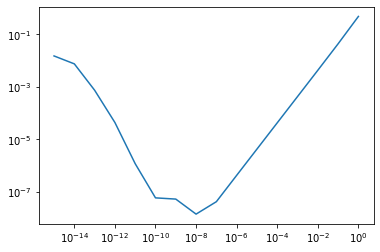

In [11]:
plt.loglog(hs, errors)

### Example 4

$f(x) = \pi - \sqrt{\pi^2-x}$, $x\in [10^{-16},10^{-14}]$

In this domain, should have $f(x) \approx x/2\pi$

In [12]:
def my_fun(x):
    return np.pi-np.sqrt(np.pi**2-x)

In [13]:
def mod_fun(x):
    return 2*x/(np.pi+np.sqrt(np.pi**2-x))

In [14]:
x = np.linspace(1e-16,1e-14, 100)

In [15]:
outputs = my_fun(x)

In [16]:
mod_out = mod_fun(x)

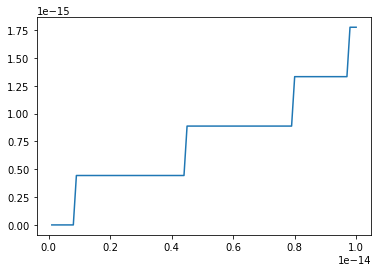

In [17]:
plt.plot(x,outputs)

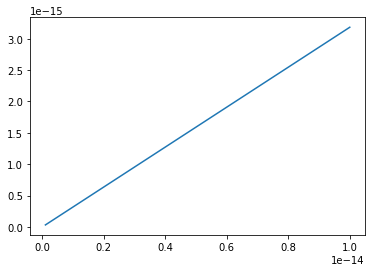

In [18]:
plt.plot(x,mod_out)

We can fix this one with a trick:
    
multiply the numerator and denominator by the conjugate, $\pi+\sqrt{\pi^2-x}$

****
## Overflow and Underflow

If a computation results in a number that is

(i) too big -> overflow  (bigger than largest float) $\approx 2^{1023}
(ii) too small -> underflow (smaller than smallest float (in magnitude)

Overflow and and underflow can normally be avoided.

### Example 1:

norm of $[x,y]$ for $x=10^{200}, y = 3\cdot10^{200}$

$\sqrt{x^2+y^2}$ will not overflow, but each of $x^2$ and $y^2$ will!

In [19]:
x = 1e200
y=3e200

In [21]:
np.sqrt(x**2+y**2)

OverflowError: (34, 'Result too large')

Observe the following:

$$\sqrt{x^2+y^2}=\max\{|x|,|y|\}\sqrt{(x/max)^2+(y/max)^2}$$

In [22]:
# define the max:

m = np.max([np.abs(x),np.abs(y)]) # here, m = y

m*np.sqrt((x/m)**2+(y/m)**2)

3.1622776601683794e+200

### Example 2: The Softmax Function

input: $x = [x_1 |x_2 | \ldots |x_n]$

output: $g(x) = [g_1 | g_2 | \ldots | g_n]$

where $g_i = \frac{e^{x_i}}{\sum_je^{x_j}}$

Observe that $g_i\in [0,1]$. However, we have a bunch of exponentials floating around that we'll have to fix.

In [26]:
def softmax_function(x):
    return np.exp(x)/np.exp(x).sum()

In [27]:
x = np.array([2,3,4,5])
softmax_function(x)

array([0.0320586 , 0.08714432, 0.23688282, 0.64391426])

In [28]:
x = np.array([700,750,789,800])

softmax_function(x)

<ipython-input-26-a9966ad4c22a>:2: RuntimeWarning: overflow encountered in exp
  return np.exp(x)/np.exp(x).sum()
<ipython-input-26-a9966ad4c22a>:2: RuntimeWarning: invalid value encountered in true_divide
  return np.exp(x)/np.exp(x).sum()


array([ 0., nan, nan, nan])

Now, see that $g_i = \frac{e^{-a}}{e^{-a}}\frac{e^{x_i}}{\sum_je^{x_j}}=\frac{e^{x_i-a}}{\sum_je^{x_j-a}}$

So, if we take $a = \max\{x_i\}$, then we should be good to go!

In [29]:
def softmax_function2(x):
    a = np.max(x)
    return np.exp(x-a)/np.exp(x-a).sum()

In [30]:
softmax_function2(x)

array([3.72001385e-44, 1.92871764e-22, 1.67014218e-05, 9.99983299e-01])

****
## Ill-Conditioning

**Condition Number**

Today: the condition number of a function $y = f(x)$

In the future: condition numbers of 1) solns of linear systems, 2) solns of least-squares problems, 3) eigenvalues and eigenvectros, etc.

The condition number of $f$ at $x$, denoted by $\kappa_f(x)$, answers: how much the relative error in $x$ is magnified by $f$.

If we have $y=f(x)$, then we have $y+\Delta y = f(x+\Delta x)$


Using Taylor's Theorem, we have $\Delta y \approx \Delta x f'(x), yielding:

$$\frac{\Delta y}{|y|} = \frac{|\Delta x||f'(x)|}{|y|} \frac{|\Delta x|}{|x|}$$

So $$\kappa_f(x) = \frac{|\Delta x||f'(x)|}{|y|}$$

If we have, say, $\kappa_f(x)\approx 1$, we say $f$ is well conditioned at $x$.

If we have, say, $\kappa_f(x) \approx 10^{16}$, we say $f$ is ill conditioned at $x$.

Rule of Thumb: if $x$ and $x+\Delta x$ agree to $p$ digits, then $y$ and $y+\Delta y$ agree to $p-\log_{10}\kappa_f(x)$


### Example:

$y =f(x) = x-1$

$\kappa_f(x) = \frac{\Delta x}{x-1}$ // ill conditioned for $x\approx 1$



In [31]:
def f(x):
    return x-1

In [32]:
def condf(x):
    return np.abs(x)-np.abs(x-1)

In [33]:
x_values = [1-10**-i for i in range (1,6)]

In [34]:
for x in x_values:
    # x + Delta x
    xdx = x+1e-16
    # y =f(x)
    y = f(x)
    # y + Delta y
    ydy = f(xdx)
    
    print('value of x')
    print(x)
    print('relative error in x')
    print(np.abs(x-xdx)/np.abs(x))
    print('relative error in y')
    print(np.abs(y-ydy)/np.abs(y))
    print('condition number')
    print(condf(x))

value of x
0.9
relative error in x
1.2335811384723962e-16
relative error in y
1.1102230246251567e-15
condition number
0.8
value of x
0.99
relative error in x
1.1214373986112693e-16
relative error in y
1.1102230246251556e-14
condition number
0.98
value of x
0.999
relative error in x
1.1113343589841408e-16
relative error in y
1.1102230246251555e-13
condition number
0.998
value of x
0.9999
relative error in x
1.1103340580309595e-16
relative error in y
1.1102230246252787e-12
condition number
0.9998
value of x
0.99999
relative error in x
1.1102341269664262e-16
relative error in y
1.1102230246302091e-11
condition number
0.9999800000000001
